# Análise e Preparação de Datasets para Reconhecimento de Expressões Faciais

## 1. Introdução ao Pré-processamento de Imagens

Para garantir que os modelos de aprendizado de máquina operem de forma eficiente e justa, é fundamental pré-processar os dados. Este notebook aborda o pipeline de pré-processamento para reconhecimento de emoções faciais, incluindo:

- Carregamento dos dados
- Redimensionamento para 96×96 pixels 
- Conversão para escala de cinza não é necessário, pois os dois datasets já são pré-baixados em escala de cinza
- Normalização dos valores dos pixels
- Balanceamento pelo número da maior classe (Oversampling) do dataset JAFFE
- Estratificação dos dados
- Separação em treino, teste;

**JAFFE**: Contém 213 imagens de 256×256 pixels em tons de cinza, com 7 emoções: 'anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise'.

**RAF-DB**: Contém 981 imagens de 48x48 pixels em tons de cinza. Semelhantes classes do JAFFE.

# IMPORTS

In [ ]:
import os #acessar e manipular diretórios e arquivos do sistema
import cv2 # OpenCV para leitura e processamento de imagens
import numpy as np #manipulação de arrays
from tqdm import tqdm #barra de progresso para visualizar carregamento de imagens
from collections import Counter #conta elementos para saber o número de imagens por classe
from sklearn.model_selection import train_test_split #separa os dados em treino e teste
from sklearn.utils import shuffle #embaralha os dados e rótulos na mesma ordem
import matplotlib.pyplot as plt #gráficos
import random
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import shutil  # necessário para remover e recriar diretórios

# Conversão das imagens dos Dataset para 96x96 e normalização dos dados

In [6]:
def load_images_from_directory(dataset_path, image_size=(96, 96)):
    """
    Carrega imagens de um diretório organizado por subpastas (uma para cada classe).

    Parâmetros:
    - dataset_path: caminho para o diretório raiz do dataset.
    - image_size: tupla com o tamanho desejado das imagens (largura, altura).

    Retorna:
    - X: numpy array contendo as imagens processadas.
    - y: numpy array contendo os rótulos (nomes das classes).
    """
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Diretório não encontrado: {dataset_path}")

    X = []  # Lista para armazenar imagens.
    y = []  # Lista para armazenar os rótulos correspondentes.

    # Obtém lista das classes a partir do nome das subpastas.
    classes = sorted(os.listdir(dataset_path))

    # Itera sobre cada classe (subpasta).
    for label in classes:
        class_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(class_dir):
            continue  # Garante que seja mesmo uma pasta.

        # Itera sobre cada arquivo de imagem na subpasta.
        for filename in tqdm(os.listdir(class_dir), desc=f'Carregando {label}'):
            filepath = os.path.join(class_dir, filename)

            # Lê a imagem.
            image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue  # Pula arquivos que não são imagens válidas.

            # Redimensiona a imagem para o tamanho padrão (96x96).
            image = cv2.resize(image, image_size)

            # Normaliza os pixels para o intervalo [0, 1].
            image = image / 255.0

            # Armazena a imagem e seu respectivo rótulo.
            X.append(image)
            y.append(label)

    # Converte as listas para arrays numpy.
    return np.array(X), np.array(y)

In [15]:
pasta_ck = '../../../datasets/ck+'
pasta_jaffe = '../../../datasets/jaffe'

X_ck, y_ck = load_images_from_directory(pasta_ck, image_size=(96, 96))
X_jaffe, y_jaffe = load_images_from_directory(pasta_jaffe, image_size=(96, 96))

print("CK+:", X_ck.shape, y_ck.shape)
print("JAFFE:", X_jaffe.shape, y_jaffe.shape)


Carregando surprise: 100%|██████████| 30/30 [00:00<00:00, 715.68it/s]

CK+: (981, 96, 96) (981,)
JAFFE: (213, 96, 96) (213,)


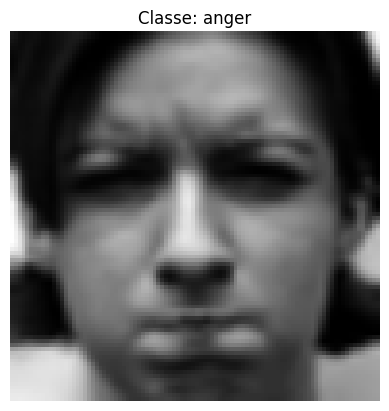

In [16]:
import matplotlib.pyplot as plt

plt.imshow(X_ck[0], cmap='gray')
plt.title(f"Classe: {y_ck[0]}")
plt.axis('off')
plt.show()


Augumentation do JAFFE

In [ ]:
# Função para aplicar augmentações simples
def augmentar_imagem(imagem):
    augmentadas = []

    # Flip horizontal
    augmentadas.append(cv2.flip(imagem, 1))

    # Rotação leve
    h, w = imagem.shape
    for ang in [-10, 10]:
        M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1)
        rot = cv2.warpAffine(imagem, M, (w, h))
        augmentadas.append(rot)

    # Ajuste de brilho
    augmentadas.append(np.clip(imagem * 1.2, 0, 255).astype(np.uint8))
    augmentadas.append(np.clip(imagem * 0.8, 0, 255).astype(np.uint8))

    # Ruído gaussiano leve
    ruido = np.random.normal(0, 5, imagem.shape)
    imagem_ruido = np.clip(imagem + ruido, 0, 255).astype(np.uint8)
    augmentadas.append(imagem_ruido)

    return augmentadas

# Função principal para aumentar o dataset JAFFE
def aumentar_jaffe(pasta_origem, pasta_destino, target_por_classe=210):
    if os.path.exists(pasta_destino):
        shutil.rmtree(pasta_destino)
    os.makedirs(pasta_destino, exist_ok=True)

    classes = sorted(os.listdir(pasta_origem))
    for classe in classes:
        caminho_classe = os.path.join(pasta_origem, classe)
        if not os.path.isdir(caminho_classe):
            continue

        destino_classe = os.path.join(pasta_destino, classe)
        os.makedirs(destino_classe, exist_ok=True)

        imagens = os.listdir(caminho_classe)
        total = 0
        idx = 0

        for nome_arquivo in tqdm(imagens, desc=f"Aumentando {classe}"):
            caminho_img = os.path.join(caminho_classe, nome_arquivo)
            img = cv2.imread(caminho_img, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            # Redimensionar para garantir tamanho uniforme
            img = cv2.resize(img, (96, 96))

            # Salvar imagem original
            cv2.imwrite(os.path.join(destino_classe, f"{classe}_{idx}.png"), img)
            total += 1
            idx += 1

            # Augmentar até atingir o total desejado
            if total < target_por_classe:
                augmentadas = augmentar_imagem(img)
                for aug in augmentadas:
                    if total >= target_por_classe:
                        break
                    cv2.imwrite(os.path.join(destino_classe, f"{classe}_{idx}.png"), aug)
                    idx += 1
                    total += 1

    return f"JAFFE aumentado para ~{target_por_classe} por classe em {pasta_destino}"


In [20]:
#Executar a função com os caminhos de diretoris

# Caminhos
pasta_origem = '../../../datasets/jaffe'
pasta_destino = '../../../datasets/jaffe_augumented'

# Executa a função
resultado = aumentar_jaffe(pasta_origem, pasta_destino, target_por_classe=150)
print(resultado)

Aumentando surprise: 100%|██████████| 30/30 [00:00<00:00, 55.92it/s]

JAFFE aumentado para ~150 por classe em ../../../datasets/jaffe_augumented


In [21]:
#Verificar visualmente se os arquivos foram criados

print(os.listdir('../../../datasets/jaffe_augumented'))

# Contar imagens por classe
for classe in os.listdir(pasta_destino):
    caminho_classe = os.path.join(pasta_destino, classe)
    if os.path.isdir(caminho_classe):
        total_imagens = len(os.listdir(caminho_classe))
        print(f"{classe}: {total_imagens} imagens")


['anger', 'disgust', 'fear', 'happy', 'neutral', 'sadness', 'surprise']
anger: 158 imagens
disgust: 157 imagens
fear: 160 imagens
happy: 159 imagens
neutral: 158 imagens
sadness: 159 imagens
surprise: 158 imagens


# Função para carregar imagens com identificação de sujeito

In [22]:
def carregar_imagens_por_sujeito(pasta, image_size=(96, 96)):
    dados = []
    classes = sorted(os.listdir(pasta))

    for classe in classes:
        caminho_classe = os.path.join(pasta, classe)
        if not os.path.isdir(caminho_classe):
            continue

        for arquivo in tqdm(os.listdir(caminho_classe), desc=f"Carregando {classe}"):
            caminho_imagem = os.path.join(caminho_classe, arquivo)
            imagem = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
            if imagem is None:
                continue

            imagem = cv2.resize(imagem, image_size)
            imagem = imagem / 255.0

            if 'jaffe' in pasta.lower():
                sujeito = arquivo[:2]  # Ex: "KA"
            elif 'ck' in pasta.lower():
                sujeito = arquivo.split('_')[0]  # Ex: "S010"
            else:
                sujeito = 'desconhecido'

            dados.append((imagem, classe, sujeito))

    return dados

# Caminhos dos datasets
pasta_jaffe = '../../../datasets/jaffe_augumented'
pasta_ck = '../../../datasets/ck+'

# Carregar os dados
dados_jaffe = carregar_imagens_por_sujeito(pasta_jaffe)
dados_ck = carregar_imagens_por_sujeito(pasta_ck)
dados = dados_jaffe + dados_ck

# Identificar sujeitos únicos
sujeitos_unicos = sorted(set(s for _, _, s in dados))

# Executar LOSO
for sujeito_teste in sujeitos_unicos:
    treino = [(x, y) for x, y, s in dados if s != sujeito_teste]
    teste = [(x, y) for x, y, s in dados if s == sujeito_teste]

    print(f"Fold - Sujeito: {sujeito_teste}")
    print(f"  Imagens de treino: {len(treino)}")
    print(f"  Imagens de teste: {len(teste)}\n")


Carregando surprise: 100%|██████████| 249/249 [00:00<00:00, 3395.79it/s]

Fold - Sujeito: S005
  Imagens de treino: 2087
  Imagens de teste: 3

Fold - Sujeito: S010
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito: S011
  Imagens de treino: 2072
  Imagens de teste: 18

Fold - Sujeito: S014
  Imagens de treino: 2078
  Imagens de teste: 12

Fold - Sujeito: S022
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito: S026
  Imagens de treino: 2078
  Imagens de teste: 12

Fold - Sujeito: S028
  Imagens de treino: 2087
  Imagens de teste: 3

Fold - Sujeito: S029
  Imagens de treino: 2087
  Imagens de teste: 3

Fold - Sujeito: S032
  Imagens de treino: 2075
  Imagens de teste: 15

Fold - Sujeito: S034
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito: S035
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito: S037
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito: S042
  Imagens de treino: 2078
  Imagens de teste: 12

Fold - Sujeito: S044
  Imagens de treino: 2081
  Imagens de teste: 9

Fold - Sujeito:

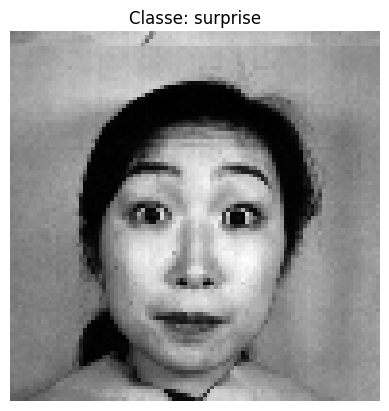

In [24]:
#validar visualmente

import matplotlib.pyplot as plt

# Visualizar uma imagem aleatória do fold de teste atual
img, label = teste[0]
plt.imshow(img, cmap='gray')
plt.title(f"Classe: {label}")
plt.axis('off')
plt.show()